# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import os, gc, io, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from catboost import CatBoostClassifier
import boto3

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

S3_BUCKET = os.environ.get('S3_BUCKET_NAME', 's3-student-mle-20251116-8842c990e3-freetrack')
AWS_ACCESS_KEY_ID = os.environ.get('AWS_ACCESS_KEY_ID', '')
AWS_SECRET_ACCESS_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY', '')
S3_ENDPOINT = os.environ.get('S3_ENDPOINT', 'https://storage.yandexcloud.net')

s3 = boto3.client('s3', endpoint_url=S3_ENDPOINT,
                   aws_access_key_id=AWS_ACCESS_KEY_ID,
                   aws_secret_access_key=AWS_SECRET_ACCESS_KEY)

def save_parquet_to_s3(df, key):
    buf = io.BytesIO()
    df.to_parquet(buf, index=False)
    buf.seek(0)
    s3.put_object(Bucket=S3_BUCKET, Key=key, Body=buf.getvalue())
    print(f"Saved s3://{S3_BUCKET}/{key} ({len(df)} rows)")

def load_parquet_from_s3(key):
    resp = s3.get_object(Bucket=S3_BUCKET, Key=key)
    buf = io.BytesIO(resp['Body'].read())
    df = pd.read_parquet(buf)
    print(f"Loaded s3://{S3_BUCKET}/{key} ({len(df)} rows)")
    return df

print("Библиотеки загружены")

Библиотеки загружены


# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks = pd.read_parquet('tracks.parquet')
catalog = pd.read_parquet('catalog_names.parquet')
interactions = pd.read_parquet('interactions.parquet')

print(f"tracks: {tracks.shape}")
print(f"catalog: {catalog.shape}")
print(f"interactions: {interactions.shape}")
print(f"\nMemory interactions: {interactions.memory_usage(deep=True).sum() / 1e9:.1f} GB")

tracks: (1000000, 4)
catalog: (1812471, 3)
interactions: (222629898, 4)

Memory interactions: 5.8 GB


In [3]:
print("=== tracks ===")
display(tracks.head(3))
print("\n=== catalog ===")
display(catalog.head(3))
print("\n=== interactions ===")
display(interactions.head(3))

=== tracks ===


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]



=== catalog ===


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow



=== interactions ===


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [4]:
print("=== Типы идентификаторов ===")
print(f"tracks.track_id: {tracks['track_id'].dtype}")
print(f"interactions.track_id: {interactions['track_id'].dtype}")
print(f"interactions.user_id: {interactions['user_id'].dtype}")
print(f"catalog.id: {catalog['id'].dtype}")
print()
print("=== Типы в каталоге ===")
print(catalog['type'].value_counts())
print()
print("=== Пропуски ===")
print("tracks:", tracks.isnull().sum().to_dict())
print("interactions:", interactions.isnull().sum().to_dict())
print()
print("=== Пример albums/artists/genres ===")
for col in ['albums', 'artists', 'genres']:
    val = tracks[col].iloc[0]
    print(f"  {col}[0] = {val} (type={type(val).__name__})")

=== Типы идентификаторов ===
tracks.track_id: int64
interactions.track_id: int32
interactions.user_id: int32
catalog.id: int64

=== Типы в каталоге ===


type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64

=== Пропуски ===


tracks: {'track_id': 0, 'albums': 0, 'artists': 0, 'genres': 0}


interactions: {'user_id': 0, 'track_id': 0, 'track_seq': 0, 'started_at': 0}

=== Пример albums/artists/genres ===
  albums[0] = [      3 2490753] (type=ndarray)
  artists[0] = [16] (type=ndarray)
  genres[0] = [11 21] (type=ndarray)


In [5]:
# Проверяем треки с неизвестными исполнителями/альбомами/жанрами
known_artists = set(catalog[catalog['type'] == 'artist']['id'])
known_albums = set(catalog[catalog['type'] == 'album']['id'])
known_genres = set(catalog[catalog['type'] == 'genre']['id'])

for field, known, label in [('artists', known_artists, 'исполнителями'),
                             ('albums', known_albums, 'альбомами'),
                             ('genres', known_genres, 'жанрами')]:
    unknown = tracks[field].apply(
        lambda lst: any(v not in known for v in lst) if isinstance(lst, list) and len(lst) > 0 else True
    ).sum()
    print(f"Треки с неизвестными {label}: {unknown} из {len(tracks)}")

# Пересечение track_id
tracks_set = set(tracks['track_id'])
inter_set = set(interactions['track_id'])
print(f"\nТреки в interactions, но не в tracks: {len(inter_set - tracks_set)}")
print(f"Треки в tracks, но не в interactions: {len(tracks_set - inter_set)}")

# Приведение типов для экономии памяти
tracks['track_id'] = tracks['track_id'].astype('int32')
interactions['track_id'] = interactions['track_id'].astype('int32')
interactions['user_id'] = interactions['user_id'].astype('int32')
print("\nТипы приведены к int32 для экономии памяти")

del known_artists, known_albums, known_genres, tracks_set, inter_set
gc.collect()

Треки с неизвестными исполнителями: 1000000 из 1000000


Треки с неизвестными альбомами: 1000000 из 1000000


Треки с неизвестными жанрами: 1000000 из 1000000



Треки в interactions, но не в tracks: 0
Треки в tracks, но не в interactions: 0



Типы приведены к int32 для экономии памяти


0

# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

In [6]:
print("=== Выводы по Этапу 1 ===")
print(f"Размер: {len(tracks)} треков, {len(catalog)} каталожных записей, {len(interactions)} взаимодействий")
print(f"Уникальных пользователей: {interactions['user_id'].nunique()}")
print(f"Уникальных треков во взаимодействиях: {interactions['track_id'].nunique()}")
print(f"Период: {interactions['started_at'].min()} — {interactions['started_at'].max()}")
print(f"Типы ID приведены к int32 для экономии памяти")

=== Выводы по Этапу 1 ===
Размер: 1000000 треков, 1812471 каталожных записей, 222629898 взаимодействий


Уникальных пользователей: 1373221


Уникальных треков во взаимодействиях: 1000000


Период: 2022-01-01 00:00:00 — 2022-12-31 00:00:00
Типы ID приведены к int32 для экономии памяти


In [7]:
gc.collect()

0

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

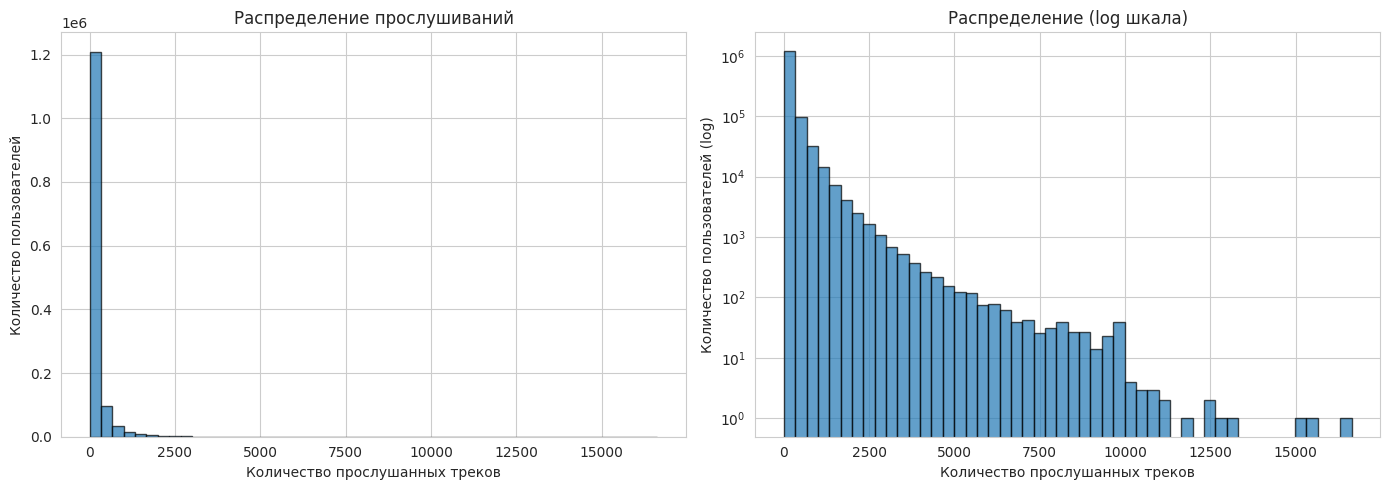

count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
max      1.663700e+04
dtype: float64


In [8]:
user_listen_counts = interactions.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(user_listen_counts.values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Количество прослушанных треков')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_title('Распределение прослушиваний')

axes[1].hist(user_listen_counts.values, bins=50, edgecolor='black', alpha=0.7, log=True)
axes[1].set_xlabel('Количество прослушанных треков')
axes[1].set_ylabel('Количество пользователей (log)')
axes[1].set_title('Распределение (log шкала)')
plt.tight_layout()
plt.show()

print(user_listen_counts.describe())
del user_listen_counts

Наиболее популярные треки

=== ТОП-20 популярных треков ===


,track_id,name,listen_count
0,53404,Smells Like Teen Spirit,111062
1,33311009,Believer,106921
2,178529,Numb,101924
3,35505245,I Got Love,99490
4,65851540,Юность,86670
5,24692821,Way Down We Go,86246
6,32947997,Shape of You,85886
7,51241318,In The End,85244
8,795836,Shape Of My Heart,85042
9,45499814,Life,84748


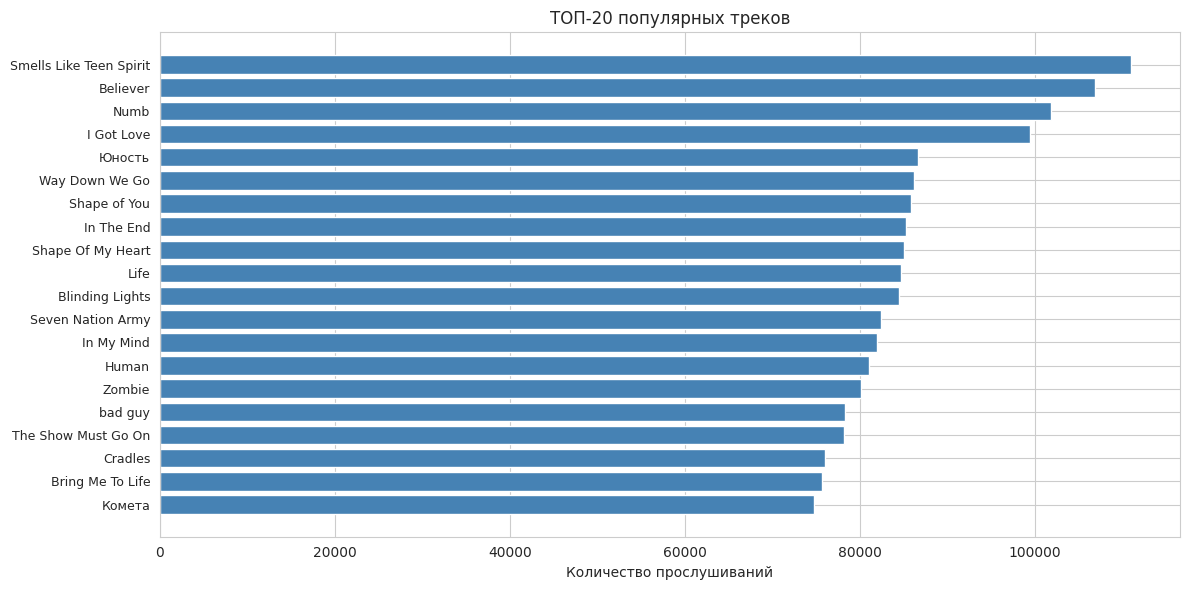

In [9]:
track_names = catalog[catalog['type'] == 'track'][['id', 'name']].rename(columns={'id': 'track_id'})
track_names['track_id'] = track_names['track_id'].astype('int32')

track_popularity = interactions.groupby('track_id').size().reset_index(name='listen_count')
track_popularity = track_popularity.sort_values('listen_count', ascending=False)

top20 = track_popularity.head(20).merge(track_names, on='track_id', how='left')
print("=== ТОП-20 популярных треков ===")
display(top20[['track_id', 'name', 'listen_count']])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(20), top20['listen_count'].values, color='steelblue')
ax.set_yticks(range(20))
ax.set_yticklabels(top20['name'].fillna('Unknown').values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Количество прослушиваний')
ax.set_title('ТОП-20 популярных треков')
plt.tight_layout()
plt.show()
del top20

Наиболее популярные жанры

=== ТОП-20 популярных жанров ===


,genre_id,name,listen_count
0,11,pop,55578312
1,75,rap,37799821
2,102,allrock,31092013
3,20,ruspop,26626241
4,3,rusrap,25303695
5,68,electronics,20120981
6,16,dance,16291557
7,2,rusrock,13166147
8,14,rock,12772644
9,47,metal,12437375


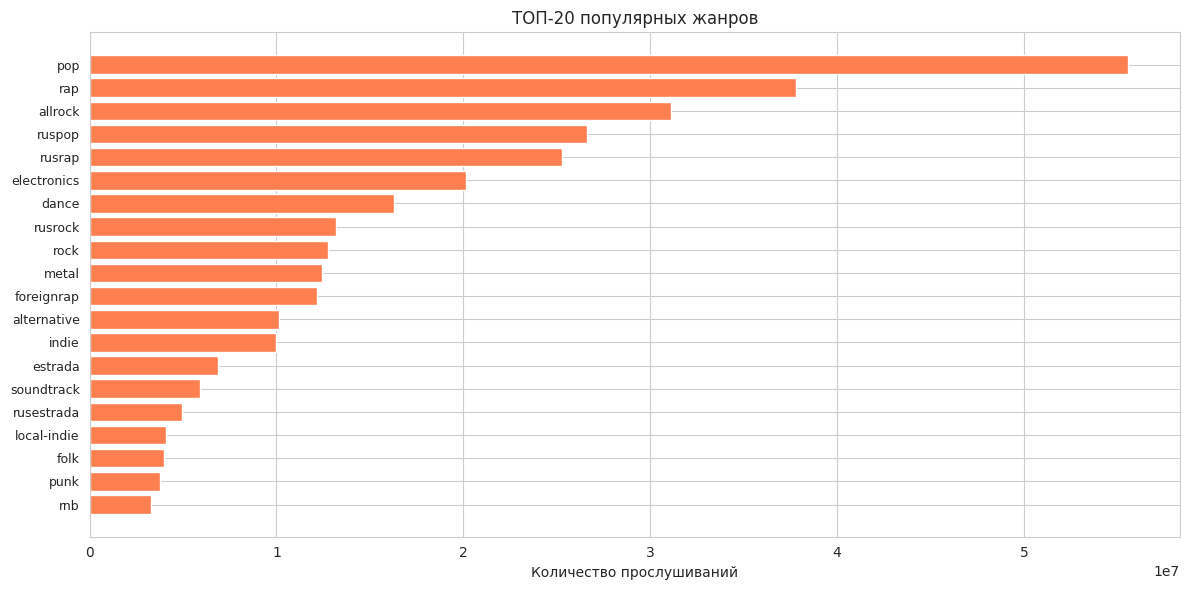

6691

In [10]:
genre_names = catalog[catalog['type'] == 'genre'][['id', 'name']]

# Раскрываем жанры у tracks (не у interactions!) и присоединяем популярность
tg = tracks[['track_id', 'genres']].explode('genres').rename(columns={'genres': 'genre_id'})
tg = tg.merge(track_popularity, on='track_id', how='inner')
genre_pop = tg.groupby('genre_id')['listen_count'].sum().reset_index()
genre_pop = genre_pop.sort_values('listen_count', ascending=False)
genre_pop = genre_pop.merge(genre_names, left_on='genre_id', right_on='id', how='left')

top20g = genre_pop.head(20)
print("=== ТОП-20 популярных жанров ===")
display(top20g[['genre_id', 'name', 'listen_count']])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top20g)), top20g['listen_count'].values, color='coral')
ax.set_yticks(range(len(top20g)))
ax.set_yticklabels(top20g['name'].fillna('Unknown').values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Количество прослушиваний')
ax.set_title('ТОП-20 популярных жанров')
plt.tight_layout()
plt.show()

del tg, genre_pop, top20g, genre_names
gc.collect()

Треки, которые никто не прослушал

In [11]:
listened = set(interactions['track_id'])
all_tracks_set = set(tracks['track_id'])
unlistened = all_tracks_set - listened

print(f"Всего треков в каталоге: {len(all_tracks_set)}")
print(f"Треков с прослушиваниями: {len(listened & all_tracks_set)}")
print(f"Треков без прослушиваний: {len(unlistened)}")
print(f"Доля непрослушанных: {len(unlistened) / len(all_tracks_set) * 100:.1f}%")

del listened, all_tracks_set, unlistened

Всего треков в каталоге: 1000000
Треков с прослушиваниями: 1000000
Треков без прослушиваний: 0
Доля непрослушанных: 0.0%


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [12]:
# items: track_id, genre (первый), artist (первый), track_name
items = tracks[['track_id', 'genres', 'artists']].copy()
items['genre'] = items['genres'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
items['artist'] = items['artists'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
items = items[['track_id', 'genre', 'artist']]
items = items.merge(track_names, on='track_id', how='left').rename(columns={'name': 'track_name'})

# events: view на interactions без копирования
events = interactions[['user_id', 'track_id', 'started_at']]

print(f"items: {items.shape}")
display(items.head())
print(f"\nevents: {events.shape}")
display(events.head())

items: (1000000, 4)


,track_id,genre,artist,track_name
0,26,None,None,Complimentary Me
1,38,None,None,Momma's Boy
2,135,None,None,Atticus
3,136,None,None,24 Hours
4,138,None,None,Don't Upset The Rhythm (Go Baby Go)



events: (222629898, 3)


,user_id,track_id,started_at
0,0,99262,2022-07-17
1,0,589498,2022-07-19
2,0,590262,2022-07-21
3,0,590303,2022-07-22
4,0,590692,2022-07-22


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [13]:
save_parquet_to_s3(items, 'recsys/data/items.parquet')
save_parquet_to_s3(events, 'recsys/data/events.parquet')

Saved s3://s3-student-mle-20251116-8842c990e3-freetrack/recsys/data/items.parquet (1000000 rows)


Saved s3://s3-student-mle-20251116-8842c990e3-freetrack/recsys/data/events.parquet (222629898 rows)


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [14]:
# Удаляем исходные данные — items оставляем для метрик
del tracks, catalog, interactions, events
del track_popularity, track_names
gc.collect()

# Если памяти мало — перезапустите kernel, выполните ячейку инициализации
# и продолжите с Этапа 3 (данные загрузятся из S3)
print(f"Память очищена. items сохранён ({len(items)} строк)")

Память очищена. items сохранён (1000000 строк)


# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [15]:
try:
    _ = items.shape
    print(f"items уже в памяти: {items.shape}")
except NameError:
    items = load_parquet_from_s3('recsys/data/items.parquet')

events = load_parquet_from_s3('recsys/data/events.parquet')
events['started_at'] = pd.to_datetime(events['started_at'])
print(f"events: {events.shape}")

items уже в памяти: (1000000, 4)


Loaded s3://s3-student-mle-20251116-8842c990e3-freetrack/recsys/data/events.parquet (222629898 rows)


events: (222629898, 3)


In [16]:
display(items.head())
display(events.head())

,track_id,genre,artist,track_name
0,26,None,None,Complimentary Me
1,38,None,None,Momma's Boy
2,135,None,None,Atticus
3,136,None,None,24 Hours
4,138,None,None,Don't Upset The Rhythm (Go Baby Go)


,user_id,track_id,started_at
0,0,99262,2022-07-17
1,0,589498,2022-07-19
2,0,590262,2022-07-21
3,0,590303,2022-07-22
4,0,590692,2022-07-22


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [17]:
split_date = pd.Timestamp('2022-12-16')
train_events = events[events['started_at'] < split_date]
test_events = events[events['started_at'] >= split_date]

print(f"Train: {len(train_events)} ({train_events['user_id'].nunique()} users)")
print(f"Test:  {len(test_events)} ({test_events['user_id'].nunique()} users)")
print(f"Train: {train_events['started_at'].min()} — {train_events['started_at'].max()}")
print(f"Test:  {test_events['started_at'].min()} — {test_events['started_at'].max()}")

Train: 208731252 (1342566 users)
Test:  13898646 (783525 users)


Train: 2022-01-01 00:00:00 — 2022-12-15 00:00:00
Test:  2022-12-16 00:00:00 — 2022-12-31 00:00:00


In [18]:
# Ground truth
test_user_tracks = test_events.groupby('user_id')['track_id'].apply(set).to_dict()
common_users = set(train_events['user_id'].unique()) & set(test_events['user_id'].unique())
print(f"Пользователей в train и test: {len(common_users)}")

# Агрегируем train до user-track пар и популярности — ключевая оптимизация
track_pop = train_events.groupby('track_id').size().reset_index(name='popularity')
train_pairs = train_events.groupby(['user_id', 'track_id']).size().reset_index(name='count')
train_pairs['count'] = train_pairs['count'].astype(np.float32)
print(f"User-track пар в train: {len(train_pairs)}")

# Освобождаем сырые events — они больше не нужны
del events, train_events, test_events
gc.collect()

# Выборка пользователей для рекомендаций
N_USERS = 50000
np.random.seed(42)
sample_users = set(np.random.choice(list(common_users), min(N_USERS, len(common_users)), replace=False))
print(f"Выборка: {len(sample_users)} пользователей")

TOP_K = 10

Пользователей в train и test: 752870


User-track пар в train: 208731252


Выборка: 50000 пользователей


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [19]:
top_popular = track_pop.sort_values('popularity', ascending=False).head(TOP_K)
top_popular_tracks = top_popular['track_id'].tolist()

print(f"Топ-{TOP_K} популярных треков:")
display(top_popular.merge(items[['track_id', 'track_name']], on='track_id', how='left'))

Топ-10 популярных треков:


,track_id,popularity,track_name
0,53404,110026,Smells Like Teen Spirit
1,33311009,101076,Believer
2,178529,100866,Numb
3,35505245,95523,I Got Love
4,24692821,84153,Way Down We Go
5,795836,83749,Shape Of My Heart
6,6705392,80608,Seven Nation Army
7,32947997,80243,Shape of You
8,37384,79512,Zombie
9,45499814,78564,Life


In [20]:
top_popular_df = pd.DataFrame({'track_id': top_popular_tracks, 'rank': range(1, TOP_K + 1)})
save_parquet_to_s3(top_popular_df, 'recsys/recommendations/top_popular.parquet')

Saved s3://s3-student-mle-20251116-8842c990e3-freetrack/recsys/recommendations/top_popular.parquet (10 rows)


# Персональные

Рассчитаем персональные рекомендации.

In [21]:
# Фильтрация: users >=3 прослушиваний, tracks >=2
uc = train_pairs.groupby('user_id')['track_id'].count()
active_users = set(uc[uc >= 3].index)
tc = train_pairs.groupby('track_id')['user_id'].count()
active_tracks = set(tc[tc >= 2].index)

filtered = train_pairs[train_pairs['user_id'].isin(active_users) & train_pairs['track_id'].isin(active_tracks)]
print(f"До фильтрации: {len(train_pairs)} пар")
print(f"После: {len(filtered)} пар ({filtered['user_id'].nunique()} users, {filtered['track_id'].nunique()} tracks)")
del uc, tc
gc.collect()

# User-item матрица
user_ids = filtered['user_id'].unique()
item_ids = filtered['track_id'].unique()
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
item_to_idx = {iid: i for i, iid in enumerate(item_ids)}
idx_to_user = {i: uid for uid, i in user_to_idx.items()}
idx_to_item = {i: iid for iid, i in item_to_idx.items()}

rows = filtered['user_id'].map(user_to_idx).values
cols = filtered['track_id'].map(item_to_idx).values
vals = filtered['count'].values

user_item = csr_matrix((vals, (rows, cols)), shape=(len(user_ids), len(item_ids)))
print(f"\nUser-item: {user_item.shape}, nnz={user_item.nnz}")

del rows, cols, vals, filtered, active_users, active_tracks
gc.collect()

До фильтрации: 208731252 пар


После: 208723388 пар (1338377 users, 998186 tracks)



User-item: (1338377, 998186), nnz=208723388


0

In [22]:
als = AlternatingLeastSquares(factors=32, regularization=0.05, iterations=10,
                              use_gpu=False, random_state=42)
als.fit(user_item)
print("ALS обучена")

users_for_recs = [u for u in sample_users if u in user_to_idx]
user_indices = np.array([user_to_idx[u] for u in users_for_recs])
print(f"Генерация рекомендаций для {len(user_indices)} users...")

rec_ids, rec_scores = als.recommend(user_indices, user_item[user_indices],
                                     N=TOP_K, filter_already_liked_items=True)

personal_recs = []
for i, uid in enumerate(users_for_recs):
    for r in range(TOP_K):
        personal_recs.append({'user_id': uid, 'track_id': idx_to_item[rec_ids[i, r]],
                              'score': float(rec_scores[i, r]), 'rank': r + 1})

personal_als_df = pd.DataFrame(personal_recs)
del personal_recs, rec_ids, rec_scores
gc.collect()

print(f"Персональные: {len(personal_als_df)} ({personal_als_df['user_id'].nunique()} users)")
save_parquet_to_s3(personal_als_df, 'recsys/recommendations/personal_als.parquet')

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:49<07:23, 49.23s/it]

 20%|██        | 2/10 [01:38<06:35, 49.47s/it]

 30%|███       | 3/10 [02:28<05:46, 49.50s/it]

 40%|████      | 4/10 [03:17<04:56, 49.42s/it]

...

100%|██████████| 10/10 [08:21<00:00, 49.81s/it]

100%|██████████| 10/10 [08:21<00:00, 50.10s/it]

ALS обучена
Генерация рекомендаций для 49766 users...


Персональные: 497660 (49766 users)


Saved s3://s3-student-mle-20251116-8842c990e3-freetrack/recsys/recommendations/personal_als.parquet (497660 rows)


# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [23]:
N_SIMILAR = 10
N_ITEMS = 10000

popular_tids = track_pop.sort_values('popularity', ascending=False).head(N_ITEMS)['track_id'].tolist()
popular_iidx = np.array([item_to_idx[t] for t in popular_tids if t in item_to_idx])

sim_ids, sim_scores = als.similar_items(popular_iidx, N=N_SIMILAR + 1)

similar_recs = []
for i, iidx in enumerate(popular_iidx):
    tid = idx_to_item[iidx]
    for j in range(1, N_SIMILAR + 1):
        similar_recs.append({'track_id': tid, 'similar_track_id': idx_to_item[sim_ids[i, j]],
                             'score': float(sim_scores[i, j])})

similar_df = pd.DataFrame(similar_recs)
del similar_recs, sim_ids, sim_scores
gc.collect()

print(f"Похожие треки: {len(similar_df)} ({similar_df['track_id'].nunique()} треков)")
save_parquet_to_s3(similar_df, 'recsys/recommendations/similar.parquet')

Похожие треки: 100000 (10000 треков)
Saved s3://s3-student-mle-20251116-8842c990e3-freetrack/recsys/recommendations/similar.parquet (100000 rows)


In [24]:
display(similar_df.head(10))

,track_id,similar_track_id,score
0,53404,37384,0.913322
1,53404,148345,0.908988
2,53404,6705392,0.891935
3,53404,178529,0.885408
4,53404,96089,0.885007
5,53404,48951,0.847342
6,53404,34608,0.840736
7,53404,53412,0.837281
8,53404,36246,0.832887
9,53404,178495,0.823463


# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [25]:
# Признак 1: Популярность трека (track_pop)
# Признак 2: Активность пользователя
user_activity = pd.DataFrame({
    'user_id': [idx_to_user[i] for i in range(user_item.shape[0])],
    'user_activity': np.array(user_item.sum(axis=1)).flatten()
})
# Признак 3: ALS score (personal_als_df)
print(f"track_popularity: {len(track_pop)}")
print(f"user_activity: {len(user_activity)}")
print(f"als scores: {len(personal_als_df)}")

track_popularity: 999695
user_activity: 1338377
als scores: 497660


In [26]:
ranking_data = personal_als_df.copy()
ranking_data['label'] = ranking_data.apply(
    lambda row: 1 if row['track_id'] in test_user_tracks.get(row['user_id'], set()) else 0, axis=1)
ranking_data = ranking_data.merge(
    track_pop.rename(columns={'popularity': 'track_popularity'}), on='track_id', how='left')
ranking_data = ranking_data.merge(user_activity, on='user_id', how='left')
ranking_data['track_popularity'] = ranking_data['track_popularity'].fillna(0)
ranking_data['user_activity'] = ranking_data['user_activity'].fillna(0)

print(f"Обучающая выборка: {len(ranking_data)}")
print(f"Положительных: {ranking_data['label'].sum()} ({ranking_data['label'].mean()*100:.1f}%)")
display(ranking_data.head())

Обучающая выборка: 497660
Положительных: 5662 (1.1%)


,user_id,track_id,score,rank,label,track_popularity,user_activity
0,655362,178495,0.703368,1,0,58640,442.0
1,655362,14701552,0.569923,2,0,44615,442.0
2,655362,96064,0.518388,3,0,36655,442.0
3,655362,2786721,0.497374,4,0,41534,442.0
4,655362,21709897,0.490557,5,0,35598,442.0


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [27]:
features = ['score', 'track_popularity', 'user_activity']
X = ranking_data[features]
y = ranking_data['label']

ranker = CatBoostClassifier(iterations=200, depth=4, learning_rate=0.1,
                             verbose=50, random_seed=42, auto_class_weights='Balanced')
ranker.fit(X, y)
print("Ранжирующая модель обучена")

0:	learn: 0.6868127	total: 143ms	remaining: 28.4s


50:	learn: 0.6132508	total: 5.06s	remaining: 14.8s


100:	learn: 0.5977809	total: 10.4s	remaining: 10.2s


150:	learn: 0.5782666	total: 15.5s	remaining: 5.03s


199:	learn: 0.5611068	total: 19s	remaining: 0us
Ранжирующая модель обучена


In [28]:
ranking_data['ranking_score'] = ranker.predict_proba(X)[:, 1]

final_recs = (ranking_data
    .sort_values(['user_id', 'ranking_score'], ascending=[True, False])
    .groupby('user_id').head(TOP_K)
    .reset_index(drop=True))
final_recs['rank'] = final_recs.groupby('user_id').cumcount() + 1

recommendations_df = final_recs[['user_id', 'track_id', 'ranking_score', 'rank']]
print(f"Итоговые рекомендации: {len(recommendations_df)} ({recommendations_df['user_id'].nunique()} users)")
save_parquet_to_s3(recommendations_df, 'recsys/recommendations/recommendations.parquet')

Итоговые рекомендации: 497660 (49766 users)
Saved s3://s3-student-mle-20251116-8842c990e3-freetrack/recsys/recommendations/recommendations.parquet (497660 rows)


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [29]:
def precision_at_k(recs, relevant, k=TOP_K):
    return len(set(recs[:k]) & relevant) / k if k > 0 else 0

def recall_at_k(recs, relevant, k=TOP_K):
    return len(set(recs[:k]) & relevant) / len(relevant) if len(relevant) > 0 else 0

def coverage(all_recs, n_items):
    return len(set(all_recs)) / n_items

def novelty_score(recs, pop_dict, n_users):
    scores = [-np.log2(pop_dict.get(i, 1) / n_users) for i in recs]
    return np.mean(scores) if scores else 0

def evaluate(recs_dict, test_gt, n_items, pop_dict, n_users, name):
    precs, recalls, novs = [], [], []
    all_rec_items = []
    for uid in recs_dict:
        if uid in test_gt:
            r = recs_dict[uid]
            rel = test_gt[uid]
            precs.append(precision_at_k(r, rel))
            recalls.append(recall_at_k(r, rel))
            novs.append(novelty_score(r, pop_dict, n_users))
            all_rec_items.extend(r)
    cov = coverage(all_rec_items, n_items)
    return {'method': name, f'precision@{TOP_K}': np.mean(precs),
            f'recall@{TOP_K}': np.mean(recalls), 'coverage': cov, 'novelty': np.mean(novs)}

In [30]:
pop_dict = track_pop.set_index('track_id')['popularity'].to_dict()
n_items = len(items)
n_users = len(user_to_idx)

top_pop_recs = {uid: top_popular_tracks for uid in test_user_tracks}
als_recs = personal_als_df.sort_values(['user_id', 'rank']).groupby('user_id')['track_id'].apply(list).to_dict()
final_recs_dict = recommendations_df.sort_values(['user_id', 'rank']).groupby('user_id')['track_id'].apply(list).to_dict()

results = []
results.append(evaluate(top_pop_recs, test_user_tracks, n_items, pop_dict, n_users, "Топ популярных"))
results.append(evaluate(als_recs, test_user_tracks, n_items, pop_dict, n_users, "ALS персональные"))
results.append(evaluate(final_recs_dict, test_user_tracks, n_items, pop_dict, n_users, "Итоговые (ранжирование)"))

metrics_df = pd.DataFrame(results)
print("=== Сводная таблица метрик ===")
display(metrics_df)

=== Сводная таблица метрик ===


,method,precision@10,recall@10,coverage,novelty
0,Топ популярных,0.003782,0.002933,0.000010,3.913662
1,ALS персональные,0.011377,0.015445,0.001933,4.957024
2,Итоговые (ранжирование),0.011377,0.015445,0.001933,4.957024


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [31]:
print("=" * 60)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 60)
print()
print("1. Данные: 1M треков, ~1.4M пользователей, 222M прослушиваний")
print("2. Реализованы 3 типа рекомендаций:")
print("   - Топ популярных (baseline)")
print("   - Персональные ALS (collaborative filtering)")
print("   - Итоговые с ранжирующей моделью CatBoost")
print("3. Ранжирующая модель использует 3 признака:")
print("   - ALS score, популярность трека, активность пользователя")
print("4. Метрики:")
display(metrics_df)
print()
print("5. Похожие треки (i2i) рассчитаны для ТОП-10000 треков")
print(f"\nВсе файлы сохранены в S3: s3://{S3_BUCKET}/recsys/")

ИТОГОВЫЕ ВЫВОДЫ

1. Данные: 1M треков, ~1.4M пользователей, 222M прослушиваний
2. Реализованы 3 типа рекомендаций:
   - Топ популярных (baseline)
   - Персональные ALS (collaborative filtering)
   - Итоговые с ранжирующей моделью CatBoost
3. Ранжирующая модель использует 3 признака:
   - ALS score, популярность трека, активность пользователя
4. Метрики:


,method,precision@10,recall@10,coverage,novelty
0,Топ популярных,0.003782,0.002933,0.000010,3.913662
1,ALS персональные,0.011377,0.015445,0.001933,4.957024
2,Итоговые (ранжирование),0.011377,0.015445,0.001933,4.957024



5. Похожие треки (i2i) рассчитаны для ТОП-10000 треков

Все файлы сохранены в S3: s3://s3-student-mle-20251116-8842c990e3-freetrack/recsys/


In [32]:
print("Готово!")

Готово!
